In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the data - assuming the first column contains the row names
df = pd.read_csv('solar_system.csv', index_col=0)

# Inspection
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nColumn names:", df.columns.tolist())
print("\nRow names (THIS IS IMPORTANT):", df.index.tolist())

Shape: (20, 10)
Rows: 20, Columns: 10

First 5 rows:
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  

Last 5 rows:
                        Mercury Venus Earth Moon  

New shape: (21, 10)


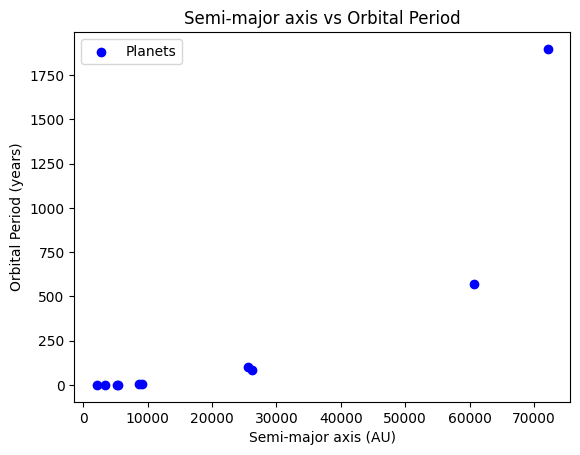

Fit: T = 0.00 * a^1.5


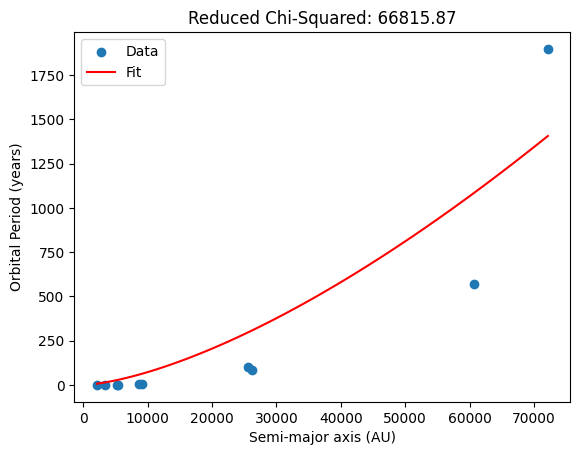

In [6]:
# Replace the numbers 0, 1, 2 with the correct row positions from your inspection
orbital_period = df.iloc[0].astype(float) 
perihelion = df.iloc[1].astype(float)
aphelion = df.iloc[2].astype(float)

# 7. Compute
semi_major_axis = (perihelion + aphelion) / 2

# 8. Add to DataFrame
# We create a Series with a name that includes units
sma_series = pd.Series(semi_major_axis, name='Semi-major axis (AU)')
df = pd.concat([df, sma_series.to_frame().T])

# 9. New Shape
print(f"New shape: {df.shape}")

# 10. Initial Plot
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planets')
plt.xlabel('Semi-major axis (AU)')
plt.ylabel('Orbital Period (years)')
plt.title('Semi-major axis vs Orbital Period')
plt.legend()
plt.show()

# 11-13. Fitting
def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]

# 14-15. Results
print(f"Fit: T = {m_fit:.2f} * a^1.5")
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2_red = np.sum(residuals**2) / (len(orbital_period) - 1)

# 16. Final Plot
plt.figure()
plt.scatter(semi_major_axis, orbital_period, label='Data')
a_smooth = np.linspace(semi_major_axis.min(), semi_major_axis.max(), 100)
plt.plot(a_smooth, keplers_third_law(a_smooth, m_fit), 'r-', label='Fit')
plt.title(f'Reduced Chi-Squared: {chi2_red:.2f}')
plt.xlabel('Semi-major axis (AU)')
plt.ylabel('Orbital Period (years)')
plt.legend()
plt.show()

In [8]:
df.to_csv("kepler.csv")